In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path

import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


DATA_FILE_CANDIDATES = [
    Path("climate_analysis/HISTALP_precipitation_solid_abs_1801-2014.nc"),
    Path("../../climate_analysis/HISTALP_precipitation_solid_abs_1801-2014.nc"),
]

data_file = next((p for p in DATA_FILE_CANDIDATES if p.exists()), None)
if data_file is None:
    raise FileNotFoundError("Could not find HISTALP file from current directory.")

ds = xr.open_dataset(data_file, decode_times=False)

month_idx = np.round(ds.time.values - 0.5).astype(int)
dates = pd.date_range("1801-01", periods=len(month_idx), freq="MS")
ds = ds.assign_coords(time=dates)

In [12]:
ds

<xarray.Dataset> Size: 261MB
Dimensions:     (time: 2568, lat: 71, lon: 179)
Coordinates:
  * time        (time) datetime64[ns] 21kB 1801-01-01 1801-02-01 ... 2014-12-01
  * lat         (lat) float64 568B 43.08 43.17 43.25 43.33 ... 48.75 48.83 48.92
  * lon         (lon) float64 1kB 4.083 4.167 4.25 4.333 ... 18.75 18.83 18.92
Data variables:
    PREC_solid  (time, lat, lon) float64 261MB ...
Attributes:
    title:           HISTALP gridded monthly solid precipitation amount 1801-...
    institution:     Zentralanstalt fuer Meteorologie und Geodynamik, Vienna,...
    conventions:     CF-1.0
    conventionsURL:  http://www.unidata.ucar.edu/packages/netcdf/conventions....
    contact:         histalp@zamg.ac.at
    references:      http://www.zamg.ac.at/histalp

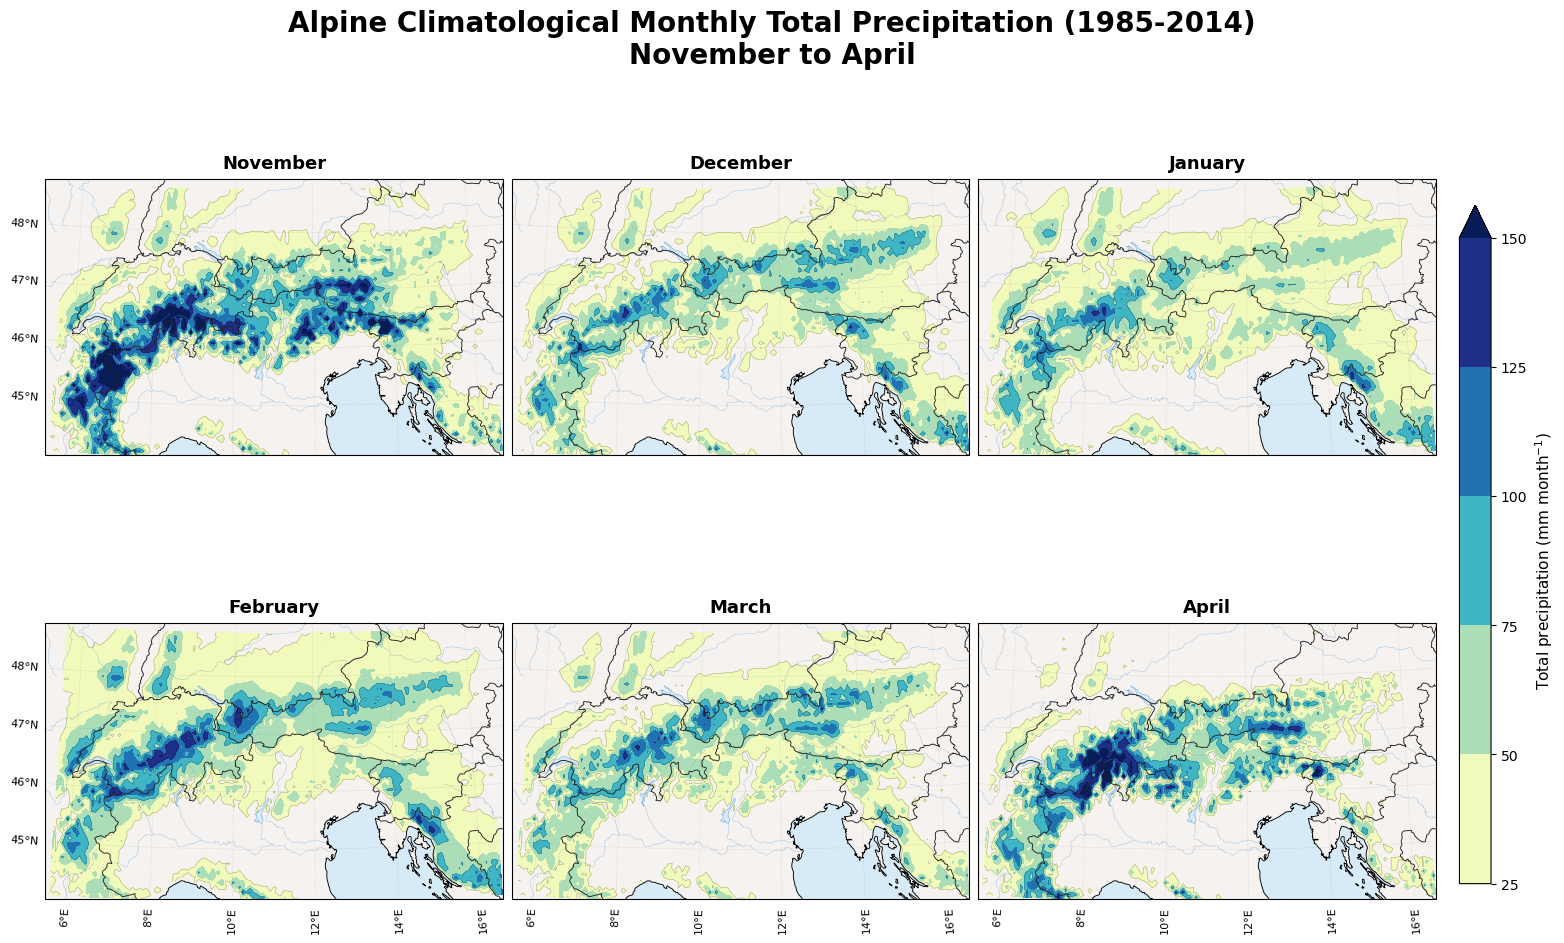

In [14]:
import matplotlib.ticker as mticker

MONTH_LABELS = {
    11: "November",
    12: "December",
    1: "January",
    2: "February",
    3: "March",
    4: "April",
}

# Use existing precipitation variable (already monthly sum in mm)
precip_da = ds["PREC_solid"]

# Climatology period
precip_clim = precip_da.sel(time=slice(f"{CLIM_START}-01-01", f"{CLIM_END}-12-31"))
precip_monthly_clim_mm = precip_clim.groupby("time.month").mean("time")

# Alpine core extent (W, E, S, N)
EXTENT_CE = [5.5, 16.5, 44.0, 48.8]
lon_name, lat_name = "lon", "lat"

# Clip to Alpine domain
ce_mask = (
    (precip_monthly_clim_mm[lon_name] >= EXTENT_CE[0]) &
    (precip_monthly_clim_mm[lon_name] <= EXTENT_CE[1]) &
    (precip_monthly_clim_mm[lat_name] >= EXTENT_CE[2]) &
    (precip_monthly_clim_mm[lat_name] <= EXTENT_CE[3])
)
precip_monthly_clim_ce = precip_monthly_clim_mm.where(ce_mask, drop=True)

PC = ccrs.PlateCarree()
# Lambert Conformal gives more realistic regional map proportions over the Alps.
PROJ = ccrs.LambertConformal(
    central_longitude=11.0,
    central_latitude=46.5,
    standard_parallels=(44.0, 49.0),
)

def add_map_features_ce(ax, show_left_labels=False, show_bottom_labels=False):
    ax.set_extent(EXTENT_CE, crs=PC)
    ax.add_feature(cfeature.LAND, facecolor="#f5f2ef", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#d6eaf8", zorder=0)
    ax.add_feature(cfeature.LAKES, facecolor="#d6eaf8", edgecolor="#5b9bd5", linewidth=0.3, zorder=1)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, edgecolor="#5b9bd5", alpha=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.65, edgecolor="#222222", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.65, zorder=3)

    gl = ax.gridlines(draw_labels=True, linewidth=0.25, color="grey", alpha=0.35, linestyle="--", zorder=4)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left_labels
    gl.bottom_labels = show_bottom_labels
    gl.x_inline = False
    gl.y_inline = False
    gl.xlocator = mticker.FixedLocator([6, 8, 10, 12, 14, 16])
    gl.ylocator = mticker.FixedLocator([44, 45, 46, 47, 48])
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

# Contour levels from data (robust scaling)
pmax = float(precip_monthly_clim_ce.sel(month=WINTER_MONTHS).quantile(0.99))
step = 25
P_LVLS = np.arange(step, np.ceil(pmax / step) * step + step, step)

fig, axes = plt.subplots(2, 3, figsize=(15.8, 10.6), subplot_kw={"projection": PROJ})
axes = axes.ravel()

for i, m in enumerate(WINTER_MONTHS):
    ax = axes[i]
    p_m = precip_monthly_clim_ce.sel(month=m)

    im = ax.contourf(
        precip_monthly_clim_ce[lon_name].values,
        precip_monthly_clim_ce[lat_name].values,
        p_m.values,
        levels=P_LVLS,
        cmap="YlGnBu",
        transform=PC,
        extend="max",
    )
    ax.contour(
        precip_monthly_clim_ce[lon_name].values,
        precip_monthly_clim_ce[lat_name].values,
        p_m.values,
        levels=P_LVLS[::2],
        colors="black",
        linewidths=0.35,
        alpha=0.35,
        transform=PC,
        zorder=10,
    )

    show_left = (i % 3 == 0)
    show_bottom = (i // 3 == 1)
    add_map_features_ce(ax, show_left_labels=show_left, show_bottom_labels=show_bottom)
    ax.set_title(MONTH_LABELS[m], fontsize=13, fontweight="bold", pad=8)

# Colorbar outside panels
cax = fig.add_axes([0.935, 0.16, 0.02, 0.64])
cb = fig.colorbar(im, cax=cax, orientation="vertical")
cb.set_label("Total precipitation (mm month$^{-1}$)", fontsize=11)
cb.ax.tick_params(labelsize=10)

fig.suptitle(
    f"Alpine Climatological Monthly Total Precipitation ({CLIM_START}-{CLIM_END})\nNovember to April",
    fontsize=20,
    fontweight="bold",
    y=0.985,
)
fig.subplots_adjust(left=0.04, right=0.92, top=0.89, bottom=0.08, wspace=0.02, hspace=0.07)
plt.show()